In [1]:
import cv2
import numpy as np

def augment_ultrasound(image):
    augmented_images = [image] # Original

    # 1. Horizontal Flip
    h_flip = cv2.flip(image, 1)
    augmented_images.append(h_flip)

    # 2. Slight Rotation (+10 deg)
    h, w = image.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), 10, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    augmented_images.append(rotated)

    # 3. Contrast / Brightness Adjustment
    # alpha 1.1 = contrast, beta 10 = brightness
    adjusted = cv2.convertScaleAbs(image, alpha=1.1, beta=10)
    augmented_images.append(adjusted)

    return augmented_images

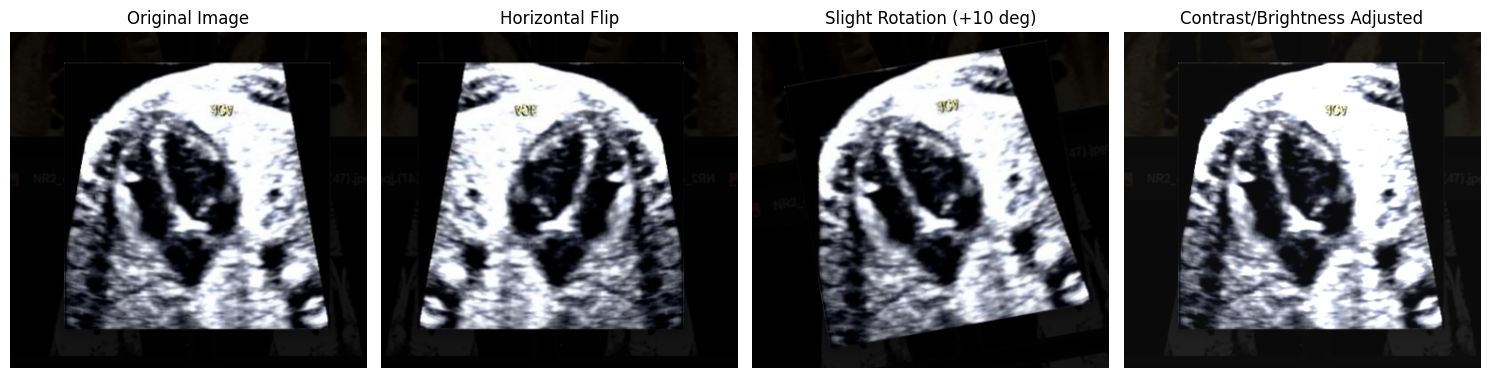

In [4]:
import matplotlib.pyplot as plt

# Path to your image file
image_path = '/content/drive/MyDrive/fchd/chd/imgi_236_default.png'

# Load the image
original_image = cv2.imread(image_path)

# Check if image was loaded successfully
if original_image is None:
    print(f"Error: Could not load image from {image_path}. Please check the path and file format.")
else:
    # OpenCV loads images in BGR format, matplotlib expects RGB
    original_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

    # Augment the image
    augmented_images = augment_ultrasound(original_image)

    # Display the images
    titles = ['Original Image', 'Horizontal Flip', 'Slight Rotation (+10 deg)', 'Contrast/Brightness Adjusted']

    plt.figure(figsize=(15, 5))
    for i, img in enumerate(augmented_images):
        # Convert augmented images to RGB for display
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, len(augmented_images), i + 1)
        plt.imshow(img_rgb)
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()